<a href="https://colab.research.google.com/github/prathameshmowade/Patern-Recognition-/blob/main/Practical_no_2_PatternR_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data
Saving wdbc.names to wdbc.names


In [3]:
import pandas as pd

df = pd.read_csv("wdbc.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [5]:
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [9]:
model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000)

In [10]:
pred_pca = model_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, pred_pca)

print("PCA Accuracy:", acc_pca)

PCA Accuracy: 0.9912280701754386


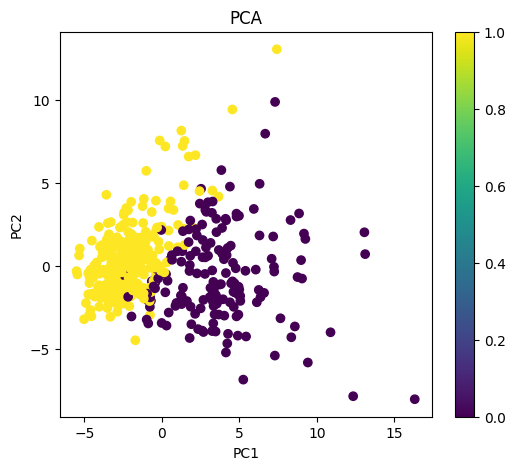

In [11]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap='viridis'
)

plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()

plt.show()

In [12]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train, y_train)

X_test_lda = lda.transform(X_test)

In [13]:
model_lda = LogisticRegression(max_iter=1000)

model_lda.fit(X_train_lda, y_train)

LogisticRegression(max_iter=1000)

In [14]:
pred_lda = model_lda.predict(X_test_lda)

acc_lda = accuracy_score(y_test, pred_lda)

print("LDA Accuracy:", acc_lda)

LDA Accuracy: 0.9473684210526315


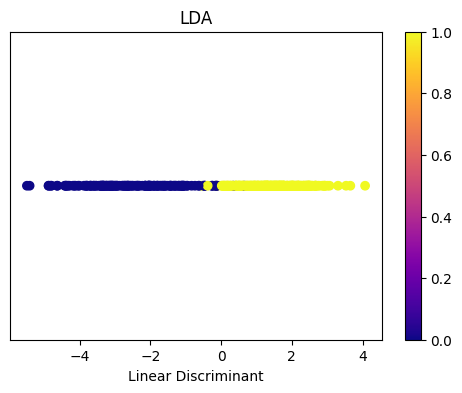

In [15]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_train_lda,
    np.zeros_like(X_train_lda),
    c=y_train,
    cmap='plasma'
)

plt.title("LDA")
plt.xlabel("Linear Discriminant")
plt.yticks([])

plt.colorbar()

plt.show()

In [16]:
print("----------- Comparison -----------")
print("PCA Accuracy :", round(acc_pca*100,2), "%")
print("LDA Accuracy :", round(acc_lda*100,2), "%")

----------- Comparison -----------
PCA Accuracy : 99.12 %
LDA Accuracy : 94.74 %
